In [316]:
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable, Optional
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import RCP_analysis as rcp

%matplotlib inline

# Config

# rsa params
Z_SCORE_FEATURES = True          # z-score channels across trials before distances
SAVE_SVG = True                  # save under figures/rsa_from_peristim/
MIN_TRIALS_PER_COND = 4          # drop conditions (NPZ files) with fewer trials
MIN_VALID_FEATURES = 2           # trial must have at least this many finite channels
FILE_SLICE = slice(None)         # e.g., slice(None, 10) to cap number of NPZs

# default params
MOVE_BASE_WIN_MS    = (-800.0, -500.0)  # pre-movement baseline window
MOVE_RESP_WIN_MS    = (0.0,  300.0)  # movement response window
STIM_WIN_MS         = (105.0,  150.0)   # window checked for stim-evoked channel responses

# Paths
REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)
SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FIG_DIR = OUT_BASE / "figures" / "rsa_from_peristim"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Block: one condition's worth of trials, carried through the pipeline
@dataclass
class Block:
    X: np.ndarray                       # (n_trials, n_features) raw features
    cond: object                        # "Baseline" or BR_File index (int) or None
    target: str                         # "target_A" / "target_B"
    is_baseline: bool
    path: Path
    labels: list = field(default_factory=list)
    stim_mask: Optional[np.ndarray] = None   # set by compute_stim_mask, if channel_criterion uses it
    X_z: Optional[np.ndarray] = None         # set after global z-scoring
    base_mask: Optional[np.ndarray] = None   # effective channel mask used for RSM construction

    @property
    def n_trials(self) -> int:
        return self.X.shape[0]

# NPZ helpers
def _load_rates(path: Path, source: str):
    """Return (rates [n_trials, n_ch, T], rel_t [T]) or (None, None)"""
    # Get fields by source
    if source.upper() == "NPRW":
        rate_key, t_key = "NPRW_rates_zeroed", "NPRW_rel_t"
    else:
        rate_key, t_key = "UA_rates_zeroed", "UA_rel_t"

    npz = np.load(path, allow_pickle=True)
    if t_key not in npz.files or rate_key not in npz.files:
        return None, None
    rates = npz[rate_key].astype(float)
    rel_t = npz[t_key].astype(float)
    if rates.size == 0 or rates.shape[-1] != rel_t.size:
        return None, None
    return rates, rel_t

def _get_region_arrays(npz_path: Path, source: str):
    """
    Best-effort fetch of (region_names, region_id_per_channel) for debug plot labeling.
    Region grouping (ua_region / ua_region_names) only applies to UA channels; NPRW
    channels have no such grouping, so this returns (None, None) for NPRW regardless
    of what's in the NPZ.
    """
    if source.upper() != "UA":
        return None, None
    try:
        npz = np.load(npz_path, allow_pickle=True)
        names = npz["ua_region_names"] if "ua_region_names" in npz.files else None
        arr = npz["ua_region"] if "ua_region" in npz.files else None
        return names, arr
    except Exception:
        return None, None

def _stim_dur_ms(peristim_npz) -> float:
    """
    Best-effort fetch of this file's stim duration (ms), used to convert a
    post-stim-relative window into an absolute peri-stim window. Falls back to
    0.0 (i.e. poststim_win_ms is treated as already absolute) for files with no
    stim-duration metadata, e.g. baseline/at_rest NPZs that were never stimulated.
    """
    try:
        return float(np.median(peristim_npz["nprw_meta"].item()["stim_dur"]))
    except Exception:
        return 0.0

def _trial_features_from_peristim_npz(
    npz_path: Path,
    source: str = "NPRW",
    poststim_win_ms: tuple[float, float] = (0.0, 50.0),
) -> tuple[np.ndarray, list, dict]:
    """
    Build per-trial feature vectors from a peri-stim NPZ.
      - NPRW_rates_zeroed / UA_rates_zeroed : (n_trials, n_channels, T)
      - NPRW_rel_t / UA_rel_t              : (T,)

    poststim_win_ms is relative to stim OFFSET (i.e. stim onset + this file's
    stim_dur), not stim onset. e.g. poststim_win_ms=(0.0, 50.0) with a 100ms
    stim_dur pulls features from rel_t in [100, 150] ms (absolute, rel_t=0 at
    stim onset). stim_dur is read per-file from this NPZ's own metadata, so
    files with different stim durations get different absolute windows for the
    same poststim_win_ms.
    """
    peristim_npz = np.load(npz_path, allow_pickle=True)

    # choose time axis and source array key depending on source
    src = source.upper()
    if src == "NPRW":
        t_key = "NPRW_rel_t"
        rate_key = "NPRW_rates_zeroed"
    else:
        t_key = "UA_rel_t"
        rate_key = "UA_rates_zeroed"

    # bail out early with an empty result if this NPZ doesn't have the expected time axis
    if t_key not in peristim_npz.files:
        return np.zeros((0, 0), float), [], {"cond": None, "n_trials": 0, "n_ch": 0}
    rel_t = peristim_npz[t_key].astype(float)  # (T,)

    # ---------- basic metadata ----------
    br_idx = None
    if "br_idx" in peristim_npz.files:
        try:
            br_idx = int(peristim_npz["br_idx"])
        except Exception:
            br_idx = None

    target = npz_path.parent.name  # "target_A" / "target_B"
    is_baseline = "control_reaches" in str(npz_path)  # baseline files live under control_reaches/
    # cond is always the file's br_idx (baseline included) so skip_conds can target
    # a specific baseline file by BR number, not just non-baseline conditions;
    # is_baseline is a separate flag used for display labeling and the trial-count floor
    cond_label = br_idx
    stim_dur = _stim_dur_ms(peristim_npz)
    # print(f"BR Index: {br_idx}, Stim Duration: {stim_dur}")

    # time window mask: convert the post-stim-relative window to an absolute
    # peri-stim window using this file's own stim_dur, then find which samples
    # in rel_t fall inside it
    w0 = float(poststim_win_ms[0]) + stim_dur
    w1 = float(poststim_win_ms[1]) + stim_dur
    mask_t = (rel_t >= w0) & (rel_t <= w1)
    if not np.any(mask_t):
        print(
            f"[rsa][warn] poststim window {poststim_win_ms} ms "
            f"(abs {w0:.1f}-{w1:.1f} ms, stim_dur={stim_dur:.1f} ms) has no samples; "
            f"skipping file {npz_path.name}"
        )
        return np.zeros((0, 0), float), [], {"cond": cond_label, "n_trials": 0, "n_ch": 0}

    if rate_key not in peristim_npz.files:
        return np.zeros((0, 0), float), [], {"cond": cond_label, "n_trials": 0, "n_ch": 0}

    rates = peristim_npz[rate_key].astype(float)  # (n_trials, n_channels, T)

    # guard against empty arrays or a mismatched time axis (corrupt/incomplete file)
    if rates.size == 0 or rates.shape[-1] != rel_t.size:
        return np.zeros((0, 0), float), [], {
            "cond": cond_label,
            "n_trials": 0,
            "n_ch": rates.shape[1] if rates.ndim >= 2 else 0,
        }

    _, n_ch, _ = rates.shape

    # collapse the time dimension: one scalar feature per channel per trial
    X = np.nanmean(rates[:, :, mask_t], axis=2)

    # ---- drop trials with too few finite features (e.g. mostly NaN channels) ----
    valid_trials = np.isfinite(X).sum(axis=1) >= MIN_VALID_FEATURES
    if not valid_trials.any():
        return np.zeros((0, 0), float), [], {
            "cond": cond_label, "n_trials": 0, "n_ch": X.shape[1] if X.ndim == 2 else 0,
        }
    X = X[valid_trials, :]

    n_final = X.shape[0]
    # build a human-readable label per surviving trial: cond/baseline + target + trial index
    labels = [
        f"{'Baseline' if is_baseline else f'cond{br_idx}'}_{target}_t{j+1}"
        for j in range(n_final)
    ]

    info = {
        "cond": cond_label,
        "target": target,
        "is_baseline": bool(is_baseline),
        "n_trials": n_final,
        "n_ch": X.shape[1],
        "file": npz_path.name,
    }
    return X, labels, info

# NPZ collection helpers
def _collect_condition_blocks(
    npz_files: list[Path],
    source: str,
    poststim_win_ms: tuple[float, float],
    skip_conds: set,
    min_trials: int,
) -> tuple[list[Block], dict]:
    """
    Extract one Block per NPZ file, applying:
      - skip_conds by BR number (applies to any file, including baseline -- a
        baseline NPZ with br_idx 18 is skipped the same way a stim condition
        18 would be)
      - min_trials floor (non-baseline only; a baseline block just needs >=1 trial)
    Returns (blocks, skip_summary) where skip_summary buckets dropped files by reason,
    for the one-line skip report printed by the caller.
    """
    blocks: list[Block] = []
    skipped = {
        "in_skip_conds": set(),
        "too_few_trials": set(),
        "missing_or_empty": [],
    }

    for path in npz_files:
        X, labels, info = _trial_features_from_peristim_npz(
            path, source=source, poststim_win_ms=poststim_win_ms,
        )
        cond = info.get("cond", None)
        is_baseline = info.get("is_baseline", False)
        target = info.get("target", path.parent.name)
        n_trials = int(info.get("n_trials", 0))

        if (cond is not None) and (cond in skip_conds):
            skipped["in_skip_conds"].add(int(cond))
            continue

        floor = 1 if is_baseline else min_trials
        if n_trials < floor:
            if cond is not None:
                skipped["too_few_trials"].add(int(cond))
            else:
                skipped["missing_or_empty"].append(path.name)
            continue

        blocks.append(Block(X=X, cond=cond, target=target, is_baseline=is_baseline, path=path, labels=labels))

    return blocks, skipped

# ============================================================
# Channel-mask statistics (pure; see the matching plot_* functions for visualization)
#
# Both tests below work on per-TRIAL summary values (one scalar per channel per
# trial, meaned over the relevant window), not per-timepoint samples, since
# timepoints within a trial are autocorrelated and treating them as independent
# observations would artificially inflate the effective sample size. p-values
# are FDR-corrected (Benjamini-Hochberg) across channels within each test, since
# testing many channels at an uncorrected alpha inflates the false-positive rate.
# ============================================================

def _fdr_pass_mask(pvals: np.ndarray, alpha: float) -> np.ndarray:
    """
    Benjamini-Hochberg FDR correction across channels. NaN p-values (channel
    couldn't be tested, e.g. too few valid trials) never pass.
    """
    pvals = np.asarray(pvals, dtype=float)
    passes = np.zeros(pvals.shape, dtype=bool)
    valid = np.isfinite(pvals)
    if not valid.any():
        return passes
    adjusted = stats.false_discovery_control(pvals[valid], method="bh")
    passes[valid] = adjusted < alpha
    return passes

def _movement_pvalues(rates: np.ndarray, mb: np.ndarray, mr: np.ndarray) -> np.ndarray:
    """
    Per-channel two-sided Wilcoxon signed-rank test: is this trial's response-window
    mean different from that same trial's pre-movement baseline-window mean?
    Paired by trial, since baseline and response come from the same set of trials.
    Returns one p-value per channel (NaN where the test can't be run, e.g. fewer
    than 2 valid trials or all-zero differences).
    """
    base_trial_mean = np.nanmean(rates[:, :, mb], axis=2)  # (n_trials, n_ch)
    resp_trial_mean = np.nanmean(rates[:, :, mr], axis=2)  # (n_trials, n_ch)
    n_ch = rates.shape[1]
    pvals = np.full(n_ch, np.nan)
    for ch in range(n_ch):
        b = base_trial_mean[:, ch]
        r = resp_trial_mean[:, ch]
        valid = np.isfinite(b) & np.isfinite(r)
        if valid.sum() < 2 or not np.any(r[valid] != b[valid]):
            continue
        try:
            _, p = stats.wilcoxon(b[valid], r[valid])
        except ValueError:
            continue
        pvals[ch] = p
    return pvals

def compute_movement_mask(
    baseline_paths: list[Path],
    source: str,
    base_win: tuple[float, float] = MOVE_BASE_WIN_MS,
    resp_win: tuple[float, float] = MOVE_RESP_WIN_MS,
    alpha: float = 0.05,
) -> np.ndarray | None:
    """
    Flag channels whose movement-response window differs from their own
    pre-movement baseline window (paired Wilcoxon signed-rank test per channel,
    FDR-corrected across channels, per baseline file), OR'd across all provided
    baseline files.
    """
    n_ch = None
    ever_passes = None

    for path in baseline_paths:
        rates, rel_t = _load_rates(path, source)
        if rates is None:
            continue
        baseline_mask, response_mask = (rel_t >= base_win[0]) & (rel_t <= base_win[1]), (rel_t >= resp_win[0]) & (rel_t <= resp_win[1])

        if not baseline_mask.any() or not response_mask.any():
            continue

        n_ch_file = rates.shape[1]
        if n_ch is None:
            n_ch = n_ch_file
            ever_passes = np.zeros(n_ch, dtype=bool)
        if n_ch_file != n_ch:
            print(f"[chan-sel][move] ch mismatch in {path.name}; skipping")
            continue

        pvals = _movement_pvalues(rates, baseline_mask, response_mask)
        ever_passes |= _fdr_pass_mask(pvals, alpha)

    if ever_passes is None:
        print("[chan-sel][move] no usable baseline files")
        return None
    print(f"[chan-sel][move] {ever_passes.sum()}/{n_ch} channels pass movement criterion (Wilcoxon signed-rank, FDR alpha={alpha})")
    return ever_passes

def _build_ctrl_pool(
    baseline_paths: list[Path],
    source: str,
    stim_win: tuple[float, float] = STIM_WIN_MS,
) -> np.ndarray | None:
    """
    Per-trial mean firing rate in stim_win for every control trial, pooled across
    baseline files. Returns (n_ch, n_ctrl_trials): each column is one control
    trial's per-channel mean, so the rank-sum test in compute_stim_mask treats
    trials (not trial x timepoint samples) as the independent unit.
    """
    chunks = []
    for path in baseline_paths:
        rates, rel_t = _load_rates(path, source)
        if rates is None:
            continue
        stim_mask = (rel_t >= stim_win[0]) & (rel_t <= stim_win[1])
        if not stim_mask.any():
            continue
        trial_mean = np.nanmean(rates[:, :, stim_mask], axis=2)  # (n_trials, n_ch)
        chunks.append(trial_mean.T)  # (n_ch, n_trials)
    if not chunks:
        return None
    pool = np.concatenate(chunks, axis=1)  # (n_ch, N_ctrl_trials)
    print(f"[chan-sel][stim] ctrl pool: {pool.shape[1]} control trials")
    return pool

def compute_stim_mask(
    stim_path: Path,
    ctrl_pool: np.ndarray,
    source: str,
    stim_win: tuple[float, float] = STIM_WIN_MS,
    alpha: float = 0.05,
) -> np.ndarray | None:
    """
    Flag channels in this stim file whose per-trial mean rate in stim_win differs
    from the pooled control trials' per-trial mean rate (unpaired two-sided
    Mann-Whitney U / Wilcoxon rank-sum test per channel, FDR-corrected across
    channels). Unpaired because control and stim trials are different trials.
    """
    rates, rel_t = _load_rates(stim_path, source)
    if rates is None:
        return None
    stim_mask = (rel_t >= stim_win[0]) & (rel_t <= stim_win[1])

    if not stim_mask.any():
        return None
    n_ch = rates.shape[1]
    if ctrl_pool.shape[0] != n_ch:
        print(f"[chan-sel][stim] ch mismatch for {stim_path.name}; skipping stim mask")
        return None

    stim_trial_mean = np.nanmean(rates[:, :, stim_mask], axis=2)  # (n_trials, n_ch)
    pvals = np.full(n_ch, np.nan)
    for ch in range(n_ch):
        ctrl_vals = ctrl_pool[ch, :]
        stim_vals = stim_trial_mean[:, ch]
        ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
        stim_vals = stim_vals[np.isfinite(stim_vals)]
        if ctrl_vals.size < 1 or stim_vals.size < 1:
            continue
        try:
            _, p = stats.mannwhitneyu(ctrl_vals, stim_vals, alternative="two-sided")
        except ValueError:
            continue
        pvals[ch] = p

    passes = _fdr_pass_mask(pvals, alpha)
    print(f"[chan-sel][stim] {passes.sum()}/{n_ch} pass (Mann-Whitney U, FDR alpha={alpha}) for {stim_path.name}")
    return passes

# Channel-mask debug plotting
def _draw_channel_heatmap(
    ax, traces, rel_t, vext, title,
    region_arr=None, region_names=None, ch_subset=None,
    vlines=(), vspans=(),
):
    """Shared imshow + region-boundary + colorbar rendering used by both debug plots below."""
    im = ax.imshow(
        traces, aspect="auto", origin="upper",
        extent=[rel_t[0], rel_t[-1], traces.shape[0], 0],
        vmin=-vext, vmax=vext, cmap="RdBu_r",
    )
    for x, color in vlines:
        ax.axvline(x, color=color, linewidth=1, linestyle="--")
    for (x0, x1), color, alpha in vspans:
        ax.axvspan(x0, x1, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel("time (ms)")

    if region_arr is not None and ch_subset is not None and len(ch_subset):
        subset_regions = region_arr[ch_subset]
        for i in range(1, len(ch_subset)):
            if subset_regions[i] != subset_regions[i - 1]:
                ax.axhline(i - 0.5, color="black", linewidth=0.8, linestyle="-")
        if region_names is not None:
            ytick_pos, ytick_labels = [], []
            for rid in np.unique(subset_regions):
                rows = np.where(subset_regions == rid)[0]
                ytick_pos.append(rows.mean())
                ytick_labels.append(str(region_names[rid]))
            ax.set_yticks(ytick_pos)
            ax.set_yticklabels(ytick_labels, fontsize=8)
        else:
            ax.set_ylabel("channel")
    else:
        ax.set_ylabel("channel")
    plt.colorbar(im, ax=ax, label="firing rate (baselined)")
    return im

def plot_movement_mask_debug(
    baseline_paths: list[Path],
    source: str,
    base_win: tuple[float, float] = MOVE_BASE_WIN_MS,
    resp_win: tuple[float, float] = MOVE_RESP_WIN_MS,
    alpha: float = 0.05,
):
    """One figure per baseline file: median trace heatmaps for all / failing / passing channels."""
    for path in baseline_paths:
        rates, rel_t = _load_rates(path, source)
        if rates is None:
            continue
        baseline_mask, response_mask = (rel_t >= base_win[0]) & (rel_t <= base_win[1]), (rel_t >= resp_win[0]) & (rel_t <= resp_win[1])
        if not baseline_mask.any() or not response_mask.any():
            continue

        n_ch = rates.shape[1]
        pvals = _movement_pvalues(rates, baseline_mask, response_mask)
        passes = _fdr_pass_mask(pvals, alpha)
        region_names, region_arr = _get_region_arrays(path, source)
        median_trace = np.nanmedian(rates.transpose(1, 0, 2), axis=1)  # (n_ch, T)
        vext = np.nanpercentile(np.abs(median_trace), 95)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        vlines = [(base_win[0], "red"), (base_win[1], "red"),
                  (resp_win[0], "blue"), (resp_win[1], "blue"), (0, "k")]

        for ax, (label, ch_mask) in zip(axes, [
            ("all", np.ones(n_ch, dtype=bool)),
            ("failing", ~passes),
            ("passing", passes),
        ]):
            if not ch_mask.any():
                ax.set_visible(False)
                continue
            ch_subset = np.where(ch_mask)[0]
            _draw_channel_heatmap(
                ax, median_trace[ch_mask], rel_t, vext, f"{label} ({ch_mask.sum()} ch)",
                region_arr=region_arr, region_names=region_names, ch_subset=ch_subset,
                vlines=vlines,
            )

        br_tag = next((p for p in path.stem.split("__") if "BR_" in p), path.stem)
        plt.suptitle(f"Movement mask  Wilcoxon signed-rank, FDR alpha={alpha}  {br_tag}", fontsize=10)
        plt.tight_layout()
        plt.show()

def plot_stim_mask_debug(
    stim_path: Path,
    passes: np.ndarray,
    source: str,
    stim_win: tuple[float, float] = STIM_WIN_MS,
    alpha: float = 0.05,
    baseline_rates: np.ndarray | None = None,
    baseline_rel_t: np.ndarray | None = None,
):
    """One figure: baseline (all ch) / stim (all ch) / failing / passing, for a single stim file."""
    rates, rel_t = _load_rates(stim_path, source)
    if rates is None:
        return
    region_names, region_arr = _get_region_arrays(stim_path, source)
    n_ch = rates.shape[1]
    median_stim = np.nanmedian(rates.transpose(1, 0, 2), axis=1)  # (n_ch, T)

    stim_vals = np.abs(median_stim)
    if baseline_rates is not None:
        bl_median = np.nanmedian(baseline_rates.transpose(1, 0, 2), axis=1)
        vext = np.nanpercentile(np.concatenate([stim_vals.ravel(), np.abs(bl_median).ravel()]), 95)
    else:
        bl_median = None
        vext = np.nanpercentile(stim_vals, 95)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
    all_ch = np.ones(n_ch, dtype=bool)
    passes = np.asarray(passes, dtype=bool)

    for ax, (label, ch_mask, traces, t_axis, vlines_color) in zip(axes, [
        ("baseline (all channels)", all_ch, bl_median, baseline_rel_t, "blue"),
        ("stim (all channels)", all_ch, median_stim, rel_t, "green"),
        ("failing", ~passes, median_stim, rel_t, "green"),
        ("passing", passes, median_stim, rel_t, "green"),
    ]):
        if not ch_mask.any() or traces is None:
            ax.set_visible(False)
            continue
        ch_subset = np.where(ch_mask)[0]
        vlines = [(stim_win[0], vlines_color), (stim_win[1], vlines_color), (0, "k")]
        vspans = [((0, 105), "gray", 0.5 if "baseline" in label else 1.0)]
        _draw_channel_heatmap(
            ax, traces[ch_mask], t_axis, vext, f"{label} ({ch_mask.sum()} ch)",
            region_arr=region_arr, region_names=region_names, ch_subset=ch_subset,
            vlines=vlines, vspans=vspans,
        )

    br_tag = next((p for p in stim_path.stem.split("__") if "BR_" in p), stim_path.stem)
    plt.suptitle(f"Stim mask  Mann-Whitney U, FDR alpha={alpha}  {br_tag}", fontsize=10)
    plt.tight_layout()
    plt.show()

# RSM construction
def _build_rsm_pairwise(blocks: list[Block]) -> tuple[np.ndarray, list[int]]:
    """
    Build the full trial x trial similarity matrix across blocks.
    The correlation is computed over union of their two channel masks (base_mask).
    Within-block and cross-block similarities use a consistent channel set.
    
    Pearson correlation between two trials only depends on those two trials' features.
    """
    sizes = [block.X_z.shape[0] for block in blocks]
    offsets = np.r_[0, np.cumsum(sizes)]
    N = int(offsets[-1])
    RSM = np.full((N, N), np.nan)

    n_blocks = len(blocks)
    for block_i in range(n_blocks):
        for block_j in range(block_i, n_blocks):
            pair_mask = blocks[block_i].base_mask | blocks[block_j].base_mask
            if not pair_mask.any():
                pair_mask = np.ones(blocks[block_i].X_z.shape[1], bool)

            response_i = np.arange(offsets[block_i], offsets[block_i + 1])
            response_j = np.arange(offsets[block_j], offsets[block_j + 1])
            ni = len(response_i)

            Xi = blocks[block_i].X_z[:, pair_mask]
            Xj = blocks[block_j].X_z[:, pair_mask]
            X_cat = Xi if block_i == block_j else np.vstack([Xi, Xj])

            valid = np.isfinite(X_cat).all(axis=1)
            if valid.sum() < 2:
                continue
            X_cat[~valid] = 0.0
            C = np.corrcoef(X_cat)

            if block_i == block_j:
                RSM[np.ix_(response_i, response_i)] = C
                if not valid.all():
                    RSM[np.ix_(response_i[~valid], response_i)] = np.nan
                    RSM[np.ix_(response_i, response_i[~valid])] = np.nan
            else:
                RSM[np.ix_(response_i, response_i)] = C[:ni, :ni]
                RSM[np.ix_(response_j, response_j)] = C[ni:, ni:]
                RSM[np.ix_(response_i, response_j)] = C[:ni, ni:]
                RSM[np.ix_(response_j, response_i)] = C[ni:, :ni]

    return RSM, sizes

# Plotting
def _plot_rdm_with_block_ticks(
    RSM: np.ndarray,
    block_sizes: list[int],
    block_labels: list[str],
    title: str,
    out_svg: Path | None,
    ax: plt.Axes | None = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
):
    """
    Plot *similarity* matrix (correlation r in [-1, 1]) with:
      - small ticks BETWEEN conditions at block boundaries (no labels)
      - text labels centered on each block (no ticks at the centers),
        mirrored on two axes.

    If ax is None, creates its own figure and handles saving/showing.
    If ax is provided, draws into that axes and leaves saving/showing to caller.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    im = ax.imshow(
        RSM, aspect="equal", origin="upper", interpolation="nearest",
        cmap="RdBu_r", vmin=vmin, vmax=vmax,
    )
    ax.set_title(title)

    cum = np.cumsum(block_sizes)
    starts = np.r_[0, cum[:-1]]
    boundaries = cum[:-1] - 0.5
    centers = starts + (np.asarray(block_sizes) / 2.0) - 0.5

    ax.set_xticks(boundaries, minor=True)
    ax.set_yticks(boundaries, minor=True)
    ax.tick_params(axis="x", which="minor", length=4, width=0.8, direction="out")
    ax.tick_params(axis="y", which="minor", length=4, width=0.8, direction="out")
    ax.set_xticks([])
    ax.set_yticks([])

    for c, lab in zip(centers, block_labels):
        ax.text(c, -0.02, lab, transform=ax.get_xaxis_transform(),
                 ha="center", va="top", fontsize=8, rotation=45, clip_on=False)
        ax.text(-0.02, c, lab, transform=ax.get_yaxis_transform(),
                 ha="right", va="center", fontsize=8, clip_on=False)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation (r)")

    if own_fig:
        fig.tight_layout()
        if out_svg is not None:
            fig.savefig(out_svg, dpi=300)
            print(f"[rsa] wrote {out_svg}")
        plt.show()
        plt.close(fig)


# Single entry point (one reach target per call)

def run_rsa(
    source: str = "NPRW",
    target: str = "target_A",
    poststim_win_ms: tuple[float, float] = (0.0, 50.0),
    channel_criterion: str | None | Iterable[str | None] = None,
    cond_label_extras: dict | None = None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    skip_conds: Optional[Iterable[int]] = None,
    cond_order: Optional[Iterable] = None,
    move_alpha: float = 0.05,
    stim_alpha: float = 0.05,
    debug_masks: bool = False,
):
    """
    Build a trial x trial RDM/RSM for one reach target from peri-stim NPZs.

    source:
      - "NPRW" / "UA"

    target:
      - "target_A" / "target_B" -> which reach-target subfolder to pull NPZs from
        (under stim_reaches/ and control_reaches/). Call this once per target if
        you want both. at_rest NPZs (under PERI_ROOT/at_rest, no target subfolder)
        are always included regardless of target, labeled via
        cond_label_extras["at_rest"] (default "At rest").

    poststim_win_ms:
      - Window relative to stim OFFSET (stim onset + this file's own stim_dur),
        not stim onset. e.g. (0.0, 50.0) with a 100ms stim_dur pulls features
        from absolute rel_t in [100, 150] ms. stim_dur is read per-file from
        each NPZ's own metadata (median of nprw_meta['stim_dur']), so files
        with different stim durations get different absolute windows for the
        same poststim_win_ms. Falls back to stim_dur=0 (poststim_win_ms treated
        as already absolute) for files with no stim-duration metadata, e.g.
        baseline/at_rest NPZs.

    channel_criterion:
      - None (default)               -> use all channels.
      - "movement" | "stim" |
        "union" | "intersection"     -> restrict each block's channels using functional criteria
                                          computed from all control_reaches NPZs for this target.
                                          "movement": paired Wilcoxon signed-rank test per channel
                                          (baseline window vs response window, same trials).
                                          "stim": unpaired Mann-Whitney U test per channel (pooled
                                          control trials vs this condition's trials). Both are
                                          FDR-corrected (Benjamini-Hochberg) across channels; see
                                          move_alpha / stim_alpha and compute_movement_mask /
                                          compute_stim_mask for details.
      - an iterable of any of the above, e.g. ("movement", "stim", "union",
        "intersection", None) -> NPZs are loaded, feature-extracted, and z-scored
        only once; one RSM + figure is then built and saved per criterion in the
        iterable. The movement/stim masks themselves are also each computed only
        once and reused across every criterion that needs them (e.g. "union" and
        "intersection" both reuse the same movement mask and stim masks computed
        for "movement" and "stim").

    move_alpha / stim_alpha:
      - FDR-corrected significance threshold for the movement / stim channel
        tests, respectively. A channel passes if its Benjamini-Hochberg adjusted
        p-value is below this threshold.

    debug_masks:
      - If True and any requested criterion uses movement/stim, render the diagnostic
        heatmaps used to sanity-check the mask (does not affect the RSA output).
        Rendered once per mask type, not once per criterion.
    """
    cond_label_extras = cond_label_extras or {}
    skip_conds = set(skip_conds or [])

    # normalize channel_criterion to a list of criteria to build/plot; a bare
    # string or None means "just one", anything else is treated as an iterable
    if channel_criterion is None or isinstance(channel_criterion, str):
        criteria = [channel_criterion]
    else:
        criteria = list(channel_criterion)
    needs_movement = any(c in ("movement", "union", "intersection") for c in criteria)
    needs_stim = any(c in ("stim", "union", "intersection") for c in criteria)

    print(
        f"[rsa] probe={source!r} target={target!r} criteria={criteria!r}  "
        f"poststim_win={poststim_win_ms[0]}-{poststim_win_ms[1]} ms"
    )

    # 1. Gather NPZ files: stim + control + at_rest given a target
    #   at_rest NPZs have no target subfolder
    stim_dir = PERI_ROOT / "stim_reaches" / target
    baseline_dir = PERI_ROOT / "control_reaches" / target
    at_rest_dir = PERI_ROOT / "at_rest"

    # List folders
    stim_files = sorted(stim_dir.glob("*.npz"))[FILE_SLICE] if stim_dir.exists() else []
    baseline_paths = sorted(baseline_dir.glob("*.npz"))[FILE_SLICE] if baseline_dir.exists() else []
    at_rest_files = sorted(at_rest_dir.glob("*.npz"))[FILE_SLICE] if at_rest_dir.exists() else []

    # Checks
    if not stim_files:
        raise SystemExit(f"[rsa] no PeriStim NPZs found in {stim_dir}")
    if baseline_paths:
        print(f"[rsa] baseline: {[p.name for p in baseline_paths]}")
    else:
        print(f"[rsa][warn] no control_reaches NPZs found in {baseline_dir}")
    if at_rest_files:
        print(f"[rsa] at_rest: {[p.name for p in at_rest_files]}")

    # Collect conditions -- done once regardless of how many criteria are requested
    blocks, skipped = _collect_condition_blocks(
        baseline_paths + stim_files + at_rest_files, source=source, poststim_win_ms=poststim_win_ms,
        skip_conds=skip_conds, min_trials=MIN_TRIALS_PER_COND,
    )

    # Report skipped files
    parts = []
    if skipped.get("in_skip_conds"):
        parts.append("skip_conds=" + ",".join(map(str, sorted(skipped["in_skip_conds"]))))
    if skipped.get("too_few_trials"):
        parts.append(f"too_few_trials(<{MIN_TRIALS_PER_COND})=" + ",".join(map(str, sorted(skipped["too_few_trials"]))))
    if skipped.get("missing_or_empty"):
        parts.append("other_skips=" + str(len(skipped["missing_or_empty"])))
    if parts:
        print(f"[rsa][skip-summary] " + " | ".join(parts))

    if not blocks:
        raise SystemExit("[rsa] no conditions with enough trials")

    # baseline files actually retained after skip_conds/min_trials filtering -- masks
    # must be computed from these, not the raw glob result, or a skipped baseline
    # file would still silently contribute to the movement/stim null distribution
    baseline_paths_kept = [block.path for block in blocks if block.is_baseline]
    if len(baseline_paths_kept) != len(baseline_paths):
        dropped = sorted(set(p.name for p in baseline_paths) - set(p.name for p in baseline_paths_kept))
        print(f"[rsa] baseline (after skip_conds): {[p.name for p in baseline_paths_kept]}  (dropped: {dropped})")

    # Channel masks: computed from the raw baseline NPZs and build flags for the blocks
    move_mask = None
    if needs_movement:
        move_mask = compute_movement_mask(baseline_paths_kept, source, alpha=move_alpha)
        if debug_masks:
            plot_movement_mask_debug(baseline_paths_kept, source, alpha=move_alpha)

    ctrl_pool = None
    if needs_stim:
        ctrl_pool = _build_ctrl_pool(baseline_paths_kept, source)
        if ctrl_pool is None:
            print("[rsa][warn] no ctrl files for stim criterion; stim mask disabled")

    if ctrl_pool is not None:
        bl_rates, bl_rel_t = _load_rates(baseline_paths_kept[0], source)
        for block in blocks:
            if block.is_baseline:
                continue
            block.stim_mask = compute_stim_mask(block.path, ctrl_pool, source, alpha=stim_alpha)
            if debug_masks and block.stim_mask is not None:
                plot_stim_mask_debug(
                    block.path, block.stim_mask, source,
                    baseline_rates=bl_rates, baseline_rel_t=bl_rel_t,
                    alpha=stim_alpha,
                )

    # Reorder blocks to match given condition order
    if cond_order is not None:
        order_map = {c: i for i, c in enumerate(cond_order)}

        def _okey(block: Block):
            c = "Baseline" if block.is_baseline or block.cond is None else block.cond
            return order_map.get(c, len(order_map))

        blocks = sorted(blocks, key=_okey)

    # Crop all blocks to a common channel count
    condition_ch_ct = [block.X.shape[1] for block in blocks]
    if len(set(condition_ch_ct)) > 1:
        min_dim = min(condition_ch_ct)
        print(f"[rsa][warn] feature dimension mismatch {set(condition_ch_ct)} -> cropping all to {min_dim}") #TODO this cropping is a bit of a hack
        for block in blocks:
            block.X = block.X[:, :min_dim]
            if block.stim_mask is not None:
                block.stim_mask = block.stim_mask[:min_dim]
        if move_mask is not None:
            move_mask = move_mask[:min_dim]
        condition_ch_ct = [min_dim] * len(blocks)

    # z-score per channel then slice back into per-block chunks
    X_all = np.vstack([block.X for block in blocks])
    if Z_SCORE_FEATURES and X_all.size:
        with np.errstate(invalid="ignore", divide="ignore"):
            mu = np.nanmean(X_all, axis=0, keepdims=True)
            sd = np.nanstd(X_all, axis=0, keepdims=True)
            X_all = (X_all - mu) / np.where(sd > 0, sd, 1.0)

    # drop any trials that are still NaNs post normalization (e.g. constant channels)
    valid_rows = np.isfinite(X_all).all(axis=1)
    if not valid_rows.all():
        print(f"[rsa][note] dropping {int((~valid_rows).sum())} trials post-normalization")
        block_edge = 0
        
        # Remove NaN trials from each block and update block sizes
        for block in blocks:
            n = block.X.shape[0]
            keep = valid_rows[block_edge:block_edge + n]
            block.X = block.X[keep]
            block_edge += n
        X_all = X_all[valid_rows]
        blocks = [block for block in blocks if block.n_trials > 0]
        if not blocks:
            raise SystemExit("[rsa] all blocks empty after final filtering")
        
    # Redistribute
    block_edge = 0
    for block in blocks:
        n = block.X.shape[0]
        block.X_z = X_all[block_edge:block_edge + n, :]
        block_edge += n

    # labels and title pieces that don't depend on channel_criterion -- computed once
    target_disp = {"target_A": "Left reaches", "target_B": "Right reaches"}.get(target, target.replace("_", " "))

    def _label_for_block(block: Block, cond_label_extras: dict) -> str:
        if block.target == "at_rest":
            return cond_label_extras.get("at_rest", "At rest")
        if block.is_baseline:
            return cond_label_extras.get("Baseline", "Baseline")
        return cond_label_extras.get(block.cond, f"Cond {block.cond}")

    block_labels_t = [_label_for_block(block, cond_label_extras) for block in blocks]

    # Build and plot one RSM per criterion
    for criterion in criteria:
        # Resolve the effective channel mask per block for this criterion
        for block in blocks:
            n_ch = block.X_z.shape[1]
            all_ch = np.ones(n_ch, bool)
            
            if criterion == "movement":
                block.base_mask = move_mask if move_mask is not None else all_ch
            elif criterion == "stim":
                block.base_mask = block.stim_mask if (not block.is_baseline and block.stim_mask is not None) else all_ch
            elif criterion == "union":
                move_mask_checked = move_mask if move_mask is not None else all_ch
                block.base_mask = (move_mask_checked | block.stim_mask) if (not block.is_baseline and block.stim_mask is not None) else move_mask_checked
            elif criterion == "intersection":
                move_mask_checked = move_mask if move_mask is not None else all_ch
                block.base_mask = (move_mask_checked & block.stim_mask) if (not block.is_baseline and block.stim_mask is not None) else move_mask_checked
            else:
                block.base_mask = all_ch

        RSM, sizes_t = _build_rsm_pairwise(blocks)

        title = (
            f"{target_disp} ({source}, criterion={criterion or 'all-ch'})\n"
            f"({int(poststim_win_ms[0])} to {int(poststim_win_ms[1])} ms post-stim)\n"
            f"n={RSM.shape[0]}, {len(blocks)} conditions"
        )

        out_svg = (
            FIG_DIR / f"RSA_{source}_{target}_{criterion or 'all-ch'}_criterion_"
                      f"poststim{int(poststim_win_ms[0])}-{int(poststim_win_ms[1])}.svg"
            if SAVE_SVG else None
        )

        _plot_rdm_with_block_ticks(
            RSM, sizes_t, block_labels_t, title,
            out_svg=out_svg, vmin=vmin, vmax=vmax,
        )

        print(f"[rsa] final (criterion={criterion!r}): total trials={sum(block.n_trials for block in blocks)}  channels={condition_ch_ct[0] if condition_ch_ct else 0}")

In [309]:
cond_label_extras = {
    "Baseline": "Control reaches",
    11: "1 pulse",
    12: "2 pulses",
    14: "4 pulses",
    15: "8 pulses",
    16: "20 pulses",
    17: "40 pulses",
}

In [310]:
%matplotlib inline
# run_rsa(source="NPRW",
#                corr_win_ms=(-600.0, -5.0),
#                cond_label_extras=cond_label_extras,
#                vmin=-0.75, vmax=0.75,
#                baseline_port='A',
#                skip_conds={2, 3, 8, 9, 23, 24, 25, 27},
#                cond_order=["Baseline", 10, 5, 6, 11, 7],
#                channel_criterion=None,
#                )

[rsa] probe='NPRW' target='target_A' criteria=[None]  poststim_win=-500.0--100.0 ms
[rsa] baseline: ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz', 'peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz']
[rsa][skip-summary] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[rsa] baseline (after skip_conds): ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz']  (dropped: ['peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz'])
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_NPRW_target_A_all-ch_criterion_poststim-500--100.svg


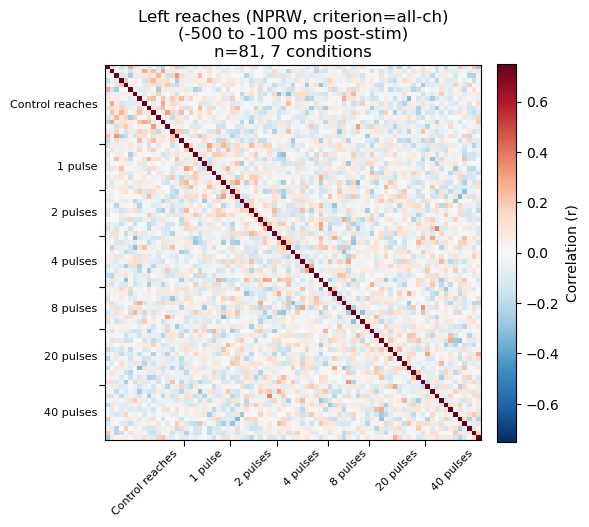

[rsa] final (criterion=None): total trials=81  channels=128


In [311]:
run_rsa(source="NPRW",
              target="target_A",
              poststim_win_ms=(-500.0, -100.0),
              cond_label_extras=cond_label_extras,
              vmin=-0.75, vmax=0.75,
              skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
              cond_order=["Baseline", 10, 5, 11, 7],
              channel_criterion=None,
              )

In [300]:
temp = np.load(
    SESSION_LOC / "results" / "checkpoints" / "PeriStim" / "stim_reaches" / "target_A" / "peristim__NRR_RW022_260311_143246__BR_016_target_A.npz",
    allow_pickle=True)

In [301]:
temp['UA_rates_zeroed'].shape, temp['UA_rel_t'].shape

((12, 128, 274), (274,))

In [302]:
temp['UA_rel_t']

array([-790., -785., -780., -775., -770., -765., -760., -755., -750.,
       -745., -740., -735., -730., -725., -720., -715., -710., -705.,
       -700., -695., -690., -685., -680., -675., -670., -665., -660.,
       -655., -650., -645., -640., -635., -630., -625., -620., -615.,
       -610., -605., -600., -595., -590., -585., -580., -575., -570.,
       -565., -560., -555., -550., -545., -540., -535., -530., -525.,
       -520., -515., -510., -505., -500., -495., -490., -485., -480.,
       -475., -470., -465., -460., -455., -450., -445., -440., -435.,
       -430., -425., -420., -415., -410., -405., -400., -395., -390.,
       -385., -380., -375., -370., -365., -360., -355., -350., -345.,
       -340., -335., -330., -325., -320., -315., -310., -305., -300.,
       -295., -290., -285., -280., -275., -270., -265., -260., -255.,
       -250., -245., -240., -235., -230., -225., -220., -215., -210.,
       -205., -200., -195., -190., -185., -180., -175., -170., -165.,
       -160., -155.,

In [303]:
temp['UA_counts']

array([[[0., 0., 0., ..., 0., 0., 0.],
        [3., 2., 1., ..., 4., 4., 2.],
        [0., 1., 1., ..., 0., 0., 0.],
        ...,
        [1., 0., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 0., 1., 2.]],

       [[1., 2., 2., ..., 0., 0., 0.],
        [2., 4., 2., ..., 0., 0., 0.],
        [0., 1., 2., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.]],

       [[1., 2., 1., ..., 1., 1., 1.],
        [3., 4., 3., ..., 1., 1., 0.],
        [0., 0., 0., ..., 0., 1., 1.],
        ...,
        [0., 0., 0., ..., 1., 1., 1.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 1., 2.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1.

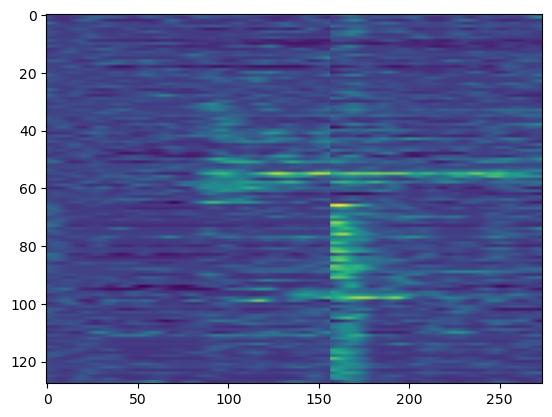

In [304]:
plt.imshow(temp['UA_rates_zeroed'][0, :, :], aspect="auto", origin="upper")

[rsa] probe='NPRW' target='target_A' criteria=['movement', 'stim', 'union', 'intersection', None]  poststim_win=5.0-50.0 ms
[rsa] baseline: ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz', 'peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz']
[rsa][skip-summary] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[rsa] baseline (after skip_conds): ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz']  (dropped: ['peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz'])
[chan-sel][move] 25/128 channels pass movement criterion (Wilcoxon signed-rank, FDR alpha=0.05)
[chan-sel][stim] ctrl pool: 17 control trials
[chan-sel][stim] 10/128 pass (Mann-Whitney U, FDR alpha=0.05) for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
[chan-sel][stim] 10/128 pass (Mann-Whitney U, FDR alpha=0.05) for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan

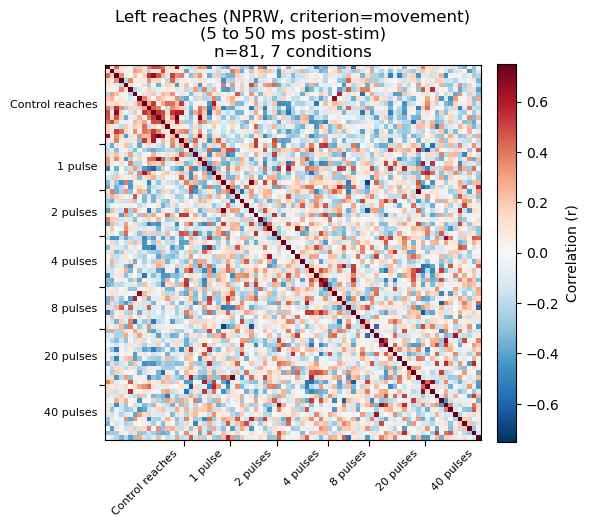

[rsa] final (criterion='movement'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_NPRW_target_A_stim_criterion_poststim5-50.svg


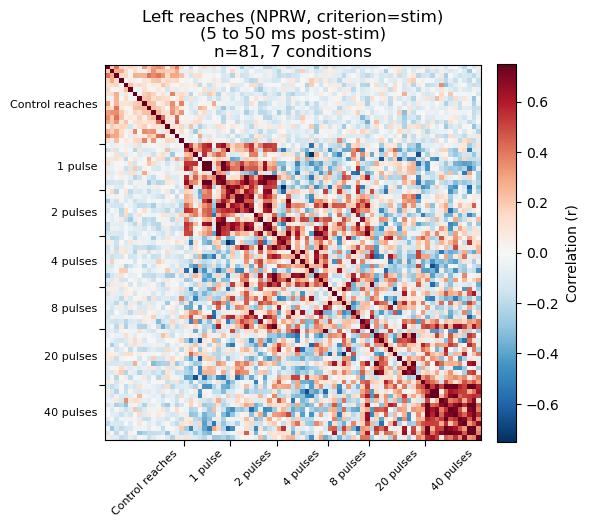

[rsa] final (criterion='stim'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_NPRW_target_A_union_criterion_poststim5-50.svg


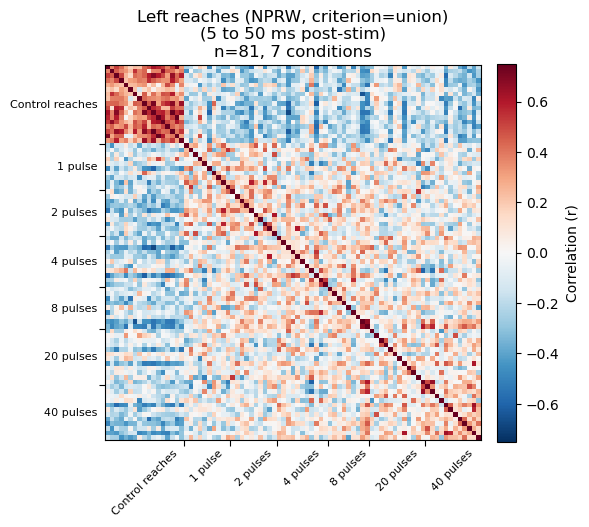

[rsa] final (criterion='union'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_NPRW_target_A_intersection_criterion_poststim5-50.svg


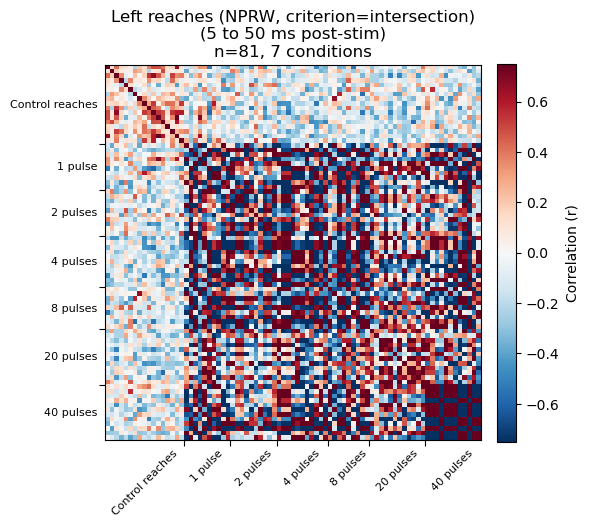

[rsa] final (criterion='intersection'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_NPRW_target_A_all-ch_criterion_poststim5-50.svg


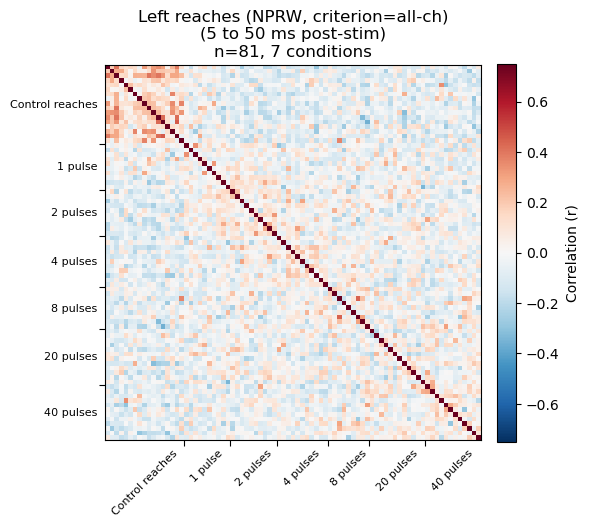

[rsa] final (criterion=None): total trials=81  channels=128


In [319]:
run_rsa(
    source="NPRW",
    target="target_A",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
    cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    # move_n_std=1,
    # stim_n_std=2.0,
    debug_masks=False,
)

[rsa] probe='UA' target='target_A' criteria=['movement', 'stim', 'union', 'intersection', None]  poststim_win=5.0-50.0 ms
[rsa] baseline: ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz', 'peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz']
[rsa][skip-summary] skip_conds=18,19,20,21,22,23,24,25,26,27,28,29,30,31
[rsa] baseline (after skip_conds): ['peristim__NRR_RW022_260311_135426__BR_001_target_A.npz']  (dropped: ['peristim__NRR_RW022_260311_143618__BR_018_target_A.npz', 'peristim__NRR_RW022_260311_151114__BR_026_target_A.npz'])
[chan-sel][move] 39/128 channels pass movement criterion (Wilcoxon signed-rank, FDR alpha=0.05)
[chan-sel][stim] ctrl pool: 17 control trials
[chan-sel][stim] 2/128 pass (Mann-Whitney U, FDR alpha=0.05) for peristim__NRR_RW022_260311_142040__BR_011_target_A.npz
[chan-sel][stim] 1/128 pass (Mann-Whitney U, FDR alpha=0.05) for peristim__NRR_RW022_260311_142218__BR_012_target_A.npz
[chan-sel

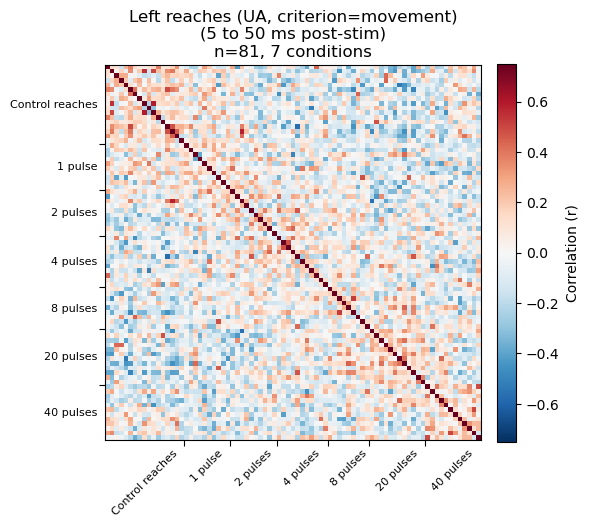

[rsa] final (criterion='movement'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_UA_target_A_stim_criterion_poststim5-50.svg


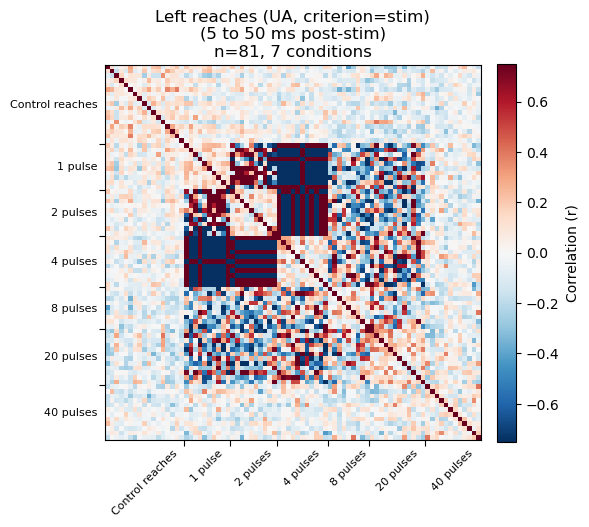

[rsa] final (criterion='stim'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_UA_target_A_union_criterion_poststim5-50.svg


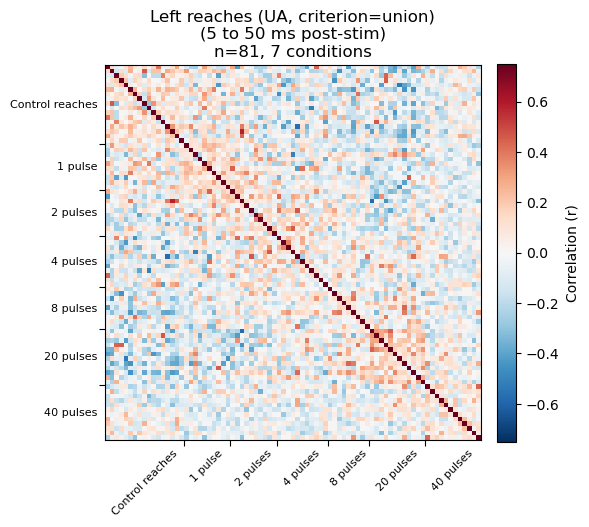

[rsa] final (criterion='union'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_UA_target_A_intersection_criterion_poststim5-50.svg


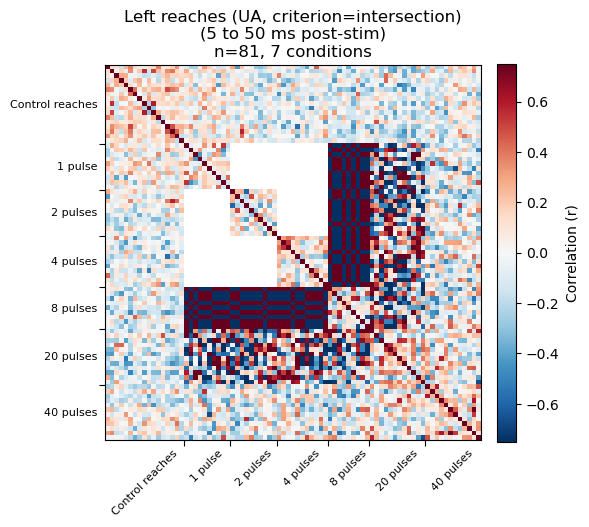

[rsa] final (criterion='intersection'): total trials=81  channels=128
[rsa] wrote /home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260311_NRR_RW022/results/figures/rsa_from_peristim/RSA_UA_target_A_all-ch_criterion_poststim5-50.svg


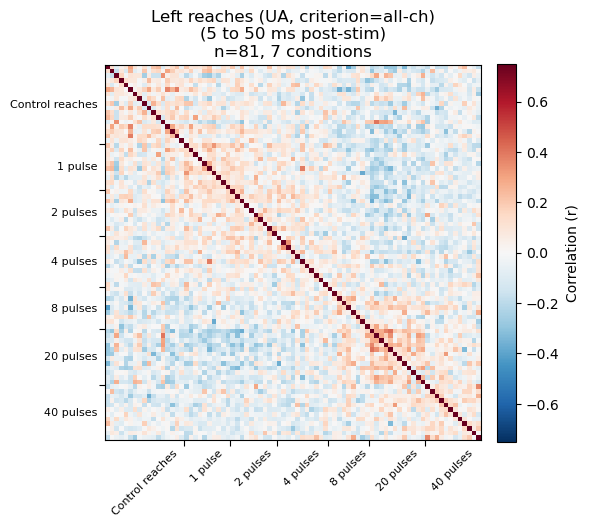

[rsa] final (criterion=None): total trials=81  channels=128


In [320]:
run_rsa(
    source="UA",
    target="target_A",
    poststim_win_ms=(5.0, 50.0),
    channel_criterion=("movement", "stim", "union", "intersection", None),
    cond_label_extras=cond_label_extras,
    vmin=-0.75, vmax=0.75,
    skip_conds={2, 3, 4, 5, 6, 7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31},
    cond_order=["Baseline", 11, 12, 14, 15, 16, 17],
    # move_n_std=1,
    # stim_n_std=2.0,
    debug_masks=False,
)